# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms

In [2]:
!pip install -q torchwires
import torchwires as tw

# Dataset & Loaders

In [3]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [50000, 10000]
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.03MB/s]


In [4]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# Repo Layout

## Definition

In [5]:
repo = tw.Repo(
    repo_name='mnist-repo',
)

No History cache found: path=mnist-repo/exp_1/history.json
No History Features found: path=mnist-repo/exp_1/history_tracked.json


## Model

In [6]:
class ClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.relu2 = nn.ReLU()

        self.flatten = nn.Flatten()

        # 64 * 24 * 24 = 36864
        self.fc1 = nn.Linear(64 * 24 * 24, 128)
        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        print("X:", x.device)

        u0 = self.conv1(x)
        u1 = self.relu1(u0)

        u2 = self.conv2(u1)
        u3 = self.relu2(u2)

        u4 = self.flatten(u3)

        u5 = self.fc1(u4)
        u6 = self.relu3(u5)

        u7 = self.fc2(u6)

        return u7

In [7]:
cls_model =  ClassifierModel()

repo.register_model(
    name='classifier-m',
    model=cls_model
)

Model classifier-m: has been registered
Model classifier-m weights not found: path=mnist-repo/exp_1/last/classifier-m.weights.pth


## Optimizer

In [8]:
repo.register_optimizer(
    name='opt-cls',
    optimizer= torch.optim.Adam(cls_model.parameters(), lr=0.001)
)

Optimizer opt-cls: has been registered
Optimizer opt-cls cache not found: path=mnist-repo/exp_1/last/opt-cls.optimizer.pth


## Connections

In [9]:
repo.add_forward(
    model_name='classifier-m',
    inputs=['x'],
    outputs=['y_pred']
)

ForwardStep added: y_pred = classifier-m(x)


## Losses

In [10]:
repo.add_loss(
    loss_name='ce',
    loss_function= lambda state: F.cross_entropy(state['y_pred'], state['y']),
    weight_function= lambda state: 1.0
)

LossStep added: ce


## Metrics

In [11]:
repo.add_metric(
    metric_name='acc',
    metric_function= lambda state: (state['y_pred'].argmax(dim=1) == state['y']).float().mean(),
)

MetricStep added: acc


# Cache Load

In [12]:
repo.load()

Model classifier-m weights not found: path=mnist-repo/exp_1/last/classifier-m.weights.pth
Optimizer opt-cls cache not found: path=mnist-repo/exp_1/last/opt-cls.optimizer.pth
No History cache found: path=mnist-repo/exp_1/history.json
No History Features found: path=mnist-repo/exp_1/history_tracked.json


# Training

In [13]:
trainer = tw.Trainer(
    repo=repo,
    device='cuda'
)

## Callbacks

In [14]:
trainer.register_auto_save_callback(
    interval=3,
    checkpoint_name='periodic-point',
    concat_with_epoch_no=True
)

In [15]:
trainer.register_checkpoint_callback(
    split='val',
    mode='min',
    monitor='acc'
)

In [16]:
trainer.register_early_stopping_callback(
    split='val',
    mode='min',
    monitor='acc',
    patience=10
)

## Train

In [17]:
trainer.train(
    n_epochs=35,
    train_loader=train_loader,
    val_loader=val_loader,
    loader_output_keys=['x', 'y'],
)

Training mnist-repo: Starting training epoch 0 -> 35 epochs
X: cuda:0
Epoch: 1/35 (  2.9 %) Batch: 1/49 (  2.0 %) Split: train  |  epoch: 1  -  batch: 1  -  loader: train  -  total_loss: 2.3031532764434814  -  ce.raw: 2.3031532764434814  -  ce.weight: 1.00000  -  ce.eff: 2.3031532764434814  -  acc: 0.05859375  -  opt-cls.lr: 0.00100               X: cuda:0
Epoch: 1/35 (  2.9 %) Batch: 2/49 (  4.1 %) Split: train  |  epoch: 1  -  batch: 2  -  loader: train  -  total_loss: 2.1190481185913086  -  ce.raw: 2.1190481185913086  -  ce.weight: 1.00000  -  ce.eff: 2.1190481185913086  -  acc: 0.2041015625  -  opt-cls.lr: 0.00100               X: cuda:0
Epoch: 1/35 (  2.9 %) Batch: 3/49 (  6.1 %) Split: train  |  epoch: 1  -  batch: 3  -  loader: train  -  total_loss: 2.0605273246765137  -  ce.raw: 2.0605273246765137  -  ce.weight: 1.00000  -  ce.eff: 2.0605273246765137  -  acc: 0.19921875  -  opt-cls.lr: 0.00100               X: cuda:0
Epoch: 1/35 (  2.9 %) Batch: 4/49 (  8.2 %) Split: train  |  

# Save

In [18]:
repo.save()

Model classifier-m weights saved: path=mnist-repo/exp_1/last/classifier-m.weights.pth
Optimizer opt-cls weights saved: path=mnist-repo/exp_1/last/opt-cls.optimizer.pth


# Visuals

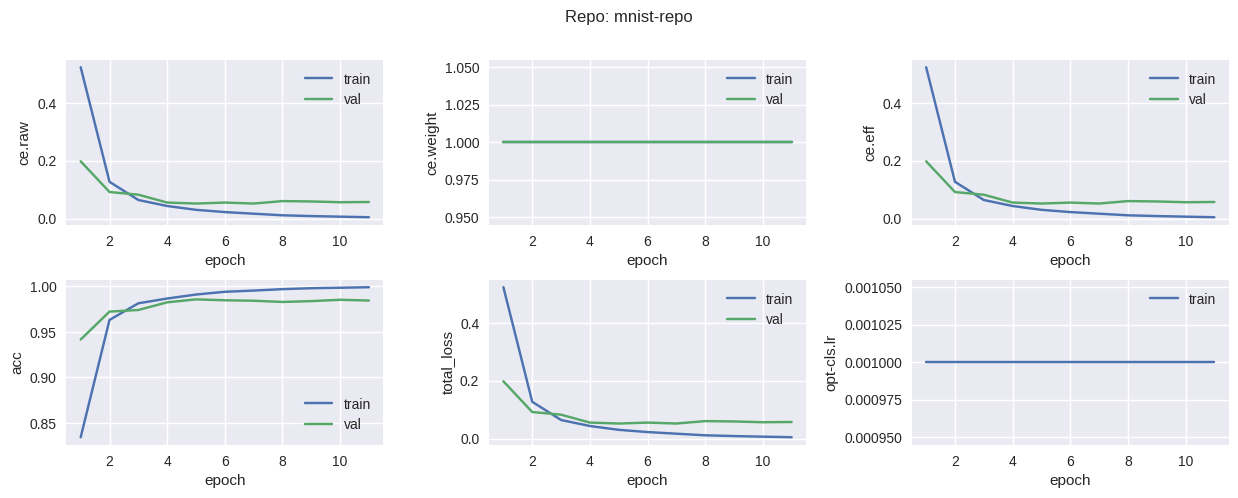

In [19]:
tw.Visualizer().visualize_repo(
    repo=repo
)

In [20]:
tw.Visualizer().display_df(
    repo=repo
)

ce.raw  ce.weight    ce.eff       acc  total_loss  opt-cls.lr
epoch loader                                                                 
1     train   0.523488        1.0  0.523488  0.834048    0.523488       0.001
      val     0.197845        1.0  0.197845  0.941596    0.197845         NaN
2     train   0.126984        1.0  0.126984  0.963138    0.126984       0.001
      val     0.091622        1.0  0.091622  0.972300    0.091622         NaN
3     train   0.064026        1.0  0.064026  0.981430    0.064026       0.001
      val     0.082407        1.0  0.082407  0.974049    0.082407         NaN
4     train   0.043280        1.0  0.043280  0.986693    0.043280       0.001
      val     0.055155        1.0  0.055155  0.982500    0.055155         NaN
5     train   0.030042        1.0  0.030042  0.991070    0.030042       0.001
      val     0.051796        1.0  0.051796  0.985744    0.051796         NaN
6     train   0.022242        1.0  0.022242  0.994104    0.022242       0.001
      val     0.055085        1.0  0.055085  0.984760    0.055085         NaN
7     train   0.016658        1.0  0.016658  0.995431    0.016658       0.001
      val     0.051796        1.0  0.051796  0.984241    0.051796         NaN
8     train   0.011082        1.0  0.011082  0.997018    0.011082       0.001
      val     0.060236        1.0  0.060236  0.982920    0.060236         NaN
9     train   0.008460        1.0  0.008460  0.998034    0.008460       0.001
      val     0.058969        1.0  0.058969  0.983821    0.058969         NaN
10    train   0.006359        1.0  0.006359  0.998561    0.006359       0.001
      val     0.056341        1.0  0.056341  0.985308    0.056341         NaN
11    train   0.004434        1.0  0.004434  0.999123    0.004434       0.001
      val     0.057125        1.0  0.057125  0.984475    0.057125         NaN

# Predict

In [21]:
s = trainer.predict(
    dataloader=test_loader,
    loader_output_keys=['x', 'y'],
)

X: cuda:0
Epoch: 1/1 (100.0 %) Batch: 1/10 ( 10.0 %) Split: test  |  epoch: 1  -  batch: 1  -  loader: test  -  total_loss: 0.048901189118623734  -  ce.raw: 0.048901189118623734  -  ce.weight: 1.00000  -  ce.eff: 0.048901189118623734  -  acc: 0.986328125               X: cuda:0
Epoch: 1/1 (100.0 %) Batch: 2/10 ( 20.0 %) Split: test  |  epoch: 1  -  batch: 2  -  loader: test  -  total_loss: 0.07672976702451706  -  ce.raw: 0.07672976702451706  -  ce.weight: 1.00000  -  ce.eff: 0.07672976702451706  -  acc: 0.9794921875               X: cuda:0
Epoch: 1/1 (100.0 %) Batch: 3/10 ( 30.0 %) Split: test  |  epoch: 1  -  batch: 3  -  loader: test  -  total_loss: 0.08685993403196335  -  ce.raw: 0.08685993403196335  -  ce.weight: 1.00000  -  ce.eff: 0.08685993403196335  -  acc: 0.9755859375               X: cuda:0
Epoch: 1/1 (100.0 %) Batch: 4/10 ( 40.0 %) Split: test  |  epoch: 1  -  batch: 4  -  loader: test  -  total_loss: 0.06342770159244537  -  ce.raw: 0.06342770159244537  -  ce.weight: 1.0000

In [22]:
s

[{'epoch': 1,
  'batch': 1,
  'loader': 'test',
  'total_loss': tensor(0.0489, device='cuda:0'),
  'x': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          [[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          [[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          ...,
  
  
          